In [1]:
import numpy as np
from scipy.optimize import fsolve
from scipy.interpolate import UnivariateSpline
from matplotlib import pyplot as plt 
from scipy.spatial.distance import euclidean

In [2]:
circle_center = np.array([1.5, 0])  # Center of the circle (cx, cy)
radius = 0.75  # Radius of the circle

In [3]:
x = np.arange(0, 3, 0.001)

In [4]:
# y = 1-np.exp(-x)
y = np.sin(6*np.pi*x)

In [5]:
def plot_fig(pts=None):
    fig, ax = plt.subplots()
    ax.plot(x,y)
    circle = plt.Circle(circle_center, radius, color="r", fill=False)
    ax.add_patch(circle)
    ax.set_aspect(1)

    if pts is not None:
        for pt in pts:
            plt.scatter(*pt)
    ax.grid()

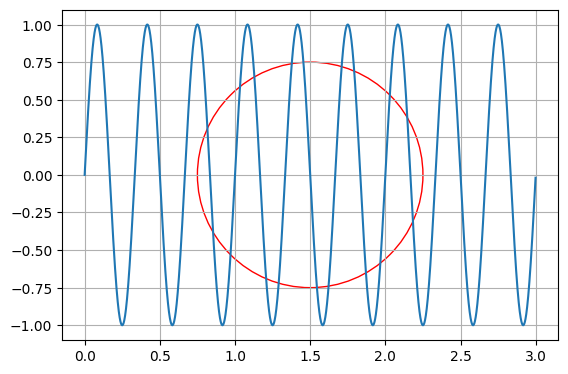

In [6]:
plot_fig()

In [7]:
o = (0,0)
p = np.stack([x,y],axis=-1)
t = np.cumsum(np.sqrt(np.sum(np.diff(p, axis=0) ** 2, axis=1)))
t = np.insert(t,0,0) / t[-1]

In [8]:
t

array([0.00000000e+00, 5.21049642e-04, 1.04191468e-03, ...,
       9.98958639e-01, 9.99479135e-01, 1.00000000e+00])

In [9]:
spline_x = UnivariateSpline(t, x, s=len(t)*0.001)
spline_y = UnivariateSpline(t, y, s=len(t) * 0.001)

In [10]:
def distance_to_circle_center(t):
    x, y = spline_x(t).item(), spline_y(t).item()
    point_on_curve = np.array([x, y])  # Point on the curve
    dist = euclidean(point_on_curve, circle_center)

    return dist - radius

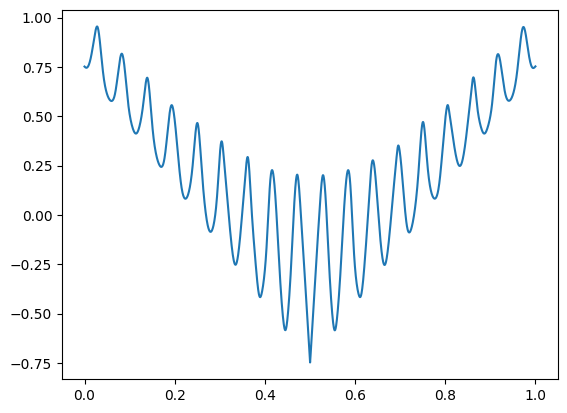

In [11]:
dd = [distance_to_circle_center(e) for e in t]
plt.plot(t, dd)

In [12]:
initial_t_guesses = np.linspace(0, 1, 100)

In [13]:
t_intersection = np.array(
    [fsolve(distance_to_circle_center, t_guess)[0] for t_guess in initial_t_guesses]
)

/home/jose/miniconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/jose/miniconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


In [14]:
t_intersection = [t for t in t_intersection if np.isclose(distance_to_circle_center(t), 0)]

In [15]:
t_intersection_unique = np.unique(np.round(t_intersection, 5))
t_intersection_unique = t_intersection_unique[
    (t_intersection_unique >= 0) & (t_intersection_unique <= 1)
]

In [16]:
intersection_points = np.array(
    [[spline_x(t), spline_y(t)] for t in t_intersection_unique]
)

In [17]:
print("Intersection points:", intersection_points)

Intersection points: [[ 0.80799931  0.28939619]
 [ 0.86954877 -0.40637458]
 [ 0.95923787 -0.51983606]
 [ 1.04797143  0.59862558]
 [ 1.11363811  0.64292154]
 [ 1.22199233 -0.69649873]
 [ 1.27703037 -0.71610663]
 [ 1.39074983  0.74184216]
 [ 1.43897865  0.74737183]
 [ 1.56083653 -0.74760229]
 [ 1.60957463 -0.7420115 ]
 [ 1.7232943   0.7158611 ]
 [ 1.77857218  0.6963455 ]
 [ 1.8850388  -0.64380783]
 [ 1.95379281 -0.59710662]
 [ 2.03961898  0.52084685]
 [ 2.13422679  0.40048334]
 [ 2.1910977  -0.29136805]]


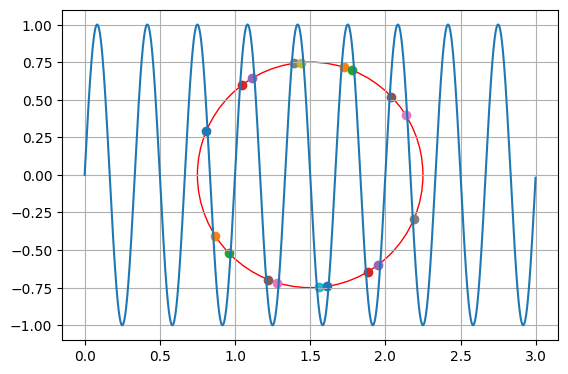

In [18]:
plot_fig(intersection_points)